# Laboratorium 4 - Aktor–krytyk

### utils

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import os

def plot_image_matrix(image_matrix, figsize=(12, 8), wspace=0., hspace=0.):
    """
    Plots a grid of images from a 2D array of file paths.

    Parameters:
    - image_matrix: 2D list or ndarray containing paths to images.
    - figsize: Tuple representing the overall figure size (width, height).
    - wspace: Padding between columns.
    - hspace: Padding between rows.
    """
    # Convert to a NumPy array to easily grab the shape
    matrix = np.array(image_matrix)

    # If the user passes a flat 1D array by mistake, convert it to 1 row
    if matrix.ndim == 1:
        matrix = matrix.reshape(1, -1)

    rows, cols = matrix.shape

    # Create the grid
    fig, axes = plt.subplots(rows, cols, figsize=figsize)

    # Matplotlib's axes array behaves weirdly with 1D. We force it to be 2D
    # so we can always index it with axes[i, j].
    if rows == 1 and cols == 1:
        axes = np.array([[axes]])
    elif rows == 1:
        axes = axes[np.newaxis, :]
    elif cols == 1:
        axes = axes[:, np.newaxis]

    # Apply the padding between rows and columns
    plt.subplots_adjust(wspace=wspace, hspace=hspace)

    # Loop through the rows and columns to plot each image
    for i in range(rows):
        for j in range(cols):
            ax = axes[i, j]
            img_path = matrix[i, j]

            # Hide the axes ticks and borders for a clean look
            ax.axis('off')

            # Check if the path is valid and exists
            if img_path and os.path.exists(img_path):
                try:
                    img = mpimg.imread(img_path)
                    ax.imshow(img)
                except Exception as e:
                    ax.text(0.5, 0.5, f"Error reading file",
                            ha='center', va='center', transform=ax.transAxes)
            else:
                # If there is an empty string/None, just leave the spot blank
                if img_path:
                    ax.text(0.5, 0.5, "File not found",
                            ha='center', va='center', transform=ax.transAxes)

    # Display the final matrix
    plt.show()


### CartPole

Skrypt zapisuje pliki `plots_cartpole/learning_{ep:05d}.png` (dwa wykresy w jednym PNG: średni kwadrat błędu TD w oknie oraz średnia nagroda w oknie). Jeśli skopiowałeś pierwszy przebieg do folderu `cartpole_single_network`, ustaw `prefix` na katalog z tymi PNG (np. `cartpole_single_network/plots_cartpole` albo sam `cartpole_single_network`, zależnie od struktury). Poniżej przykład **siatki 4×4** — dostosuj macierz `episodes_grid` do epizodów, dla których masz zapisane pliki.

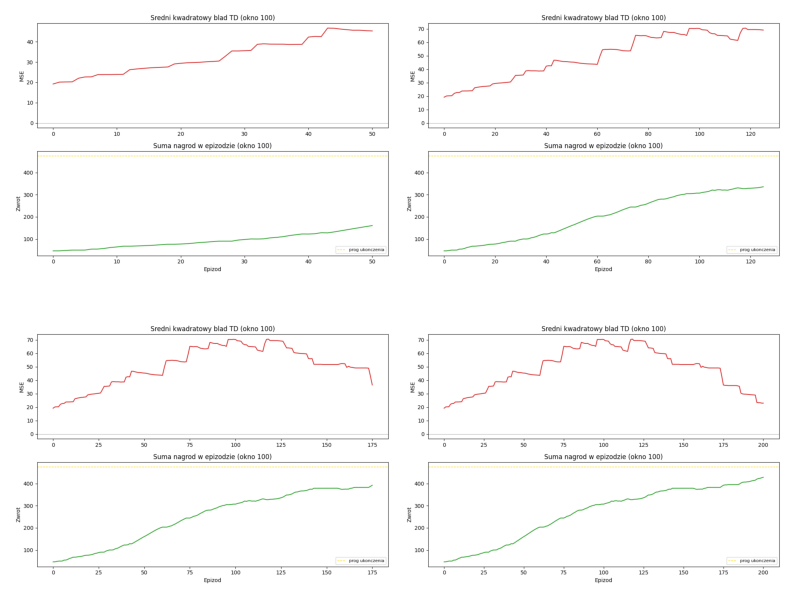

In [ ]:
prefix = "cartpole_single_network/plots_cartpole"

episodes_grid = [
    [150, 225],
    [275, 300],
]
img_matrix = [[f"{prefix}/learning_{ep:05d}.png" for ep in row] for row in episodes_grid]

plot_image_matrix(img_matrix, figsize=(10, 8), wspace=0.02, hspace=0.02)

## Cel laboratorium

Celem laboratorium jest dokończenie implementacji algorytmu uczącego się typu **aktor–krytyk** (wariant TD(0), on-policy, z regularyzacją entropii tam, gdzie jest potrzebna), a następnie sprawdzenie działania na prostym problemie **CartPole-v1** i trudniejszym **LunarLander-v3**. W treści zadania (`ladownik.pdf`) aktor i krytyk mogą początkowo **współdzielić** wczesne warstwy sieci, żeby przyspieszyć uczenie — ten dokument opisuje właśnie ten pierwszy wariant dla kijka.

Uruchomienie treningu (z poziomu katalogu `l4`):

```bash
KERAS_BACKEND=torch python solution.py --env cartpole
```

## Implementacja (`solution.py`)

### Architektura ze wspólnym trzonem

Funkcja `build_actor_critic` buduje jedną gałąź `fc1` → `fc2` z aktywacją `tanh`, a na końcu rozdziela się na **logity** akcji (bez softmax w sieci) oraz **wartość stanu** `V(s)` z liniową warstwą wyjściową. Softmax i log-prawdopodobieństwa liczymy w stracie numerycznie (log-sum-exp).

```python
def build_actor_critic(obs_dim, n_actions, hidden=(256, 256)) -> keras.Model:
    obs = keras.Input(shape=(obs_dim,), name="obs")
    x = keras.layers.Dense(hidden[0], activation="tanh", name="fc1")(obs)
    x = keras.layers.Dense(hidden[1], activation="tanh", name="fc2")(x)
    logits = keras.layers.Dense(n_actions, name="logits")(x)
    value = keras.layers.Dense(1, name="value")(x)
    return keras.Model(inputs=obs, outputs=[logits, value], name="ActorCritic")
```

Wybór akcji w `choose_action`: inferencja `model(x, training=False)`, `keras.ops.softmax` na logitach, konwersja do NumPy, normalizacja i losowanie `np.random.choice` — polityka jest stochastyczna zgodnie z rozkładem π(a|s).

### Strata (TD, krytyk, aktor, entropia)

W `compute_loss`:

- **Cel TD:** R + γ·(1 − terminated)·V(s′), przy czym V(s′) ma **`stop_gradient`** — inaczej krytyk mógłby „oszukiwać" obniżając wartość następnego stanu zamiast dopasowywać V(s) do rzeczywistego sygnału.
- **Błąd** δ = target − V(s); strata krytyka δ².
- **Aktor:** −stop_gradient(δ)·log π(a|s) — gradient polityki; **`stop_gradient` na δ** zapobiega temu, by aktor manipulował wagami krytyka zamiast poprawiać zachowanie.
- **Entropia:** dla CartPole w konfiguracji domyślnej β = 0, więc bonus entropii nie zmienia uczenia.

Gradienty dla zmiennych Keras z backendem PyTorch liczone są przez `loss.backward()` i `optimizer.apply(grads, ...)` w `compute_grads` / `learn`.

### Pętla treningu

W `train` dla każdego epizodu agent wykonuje kroki środowiska; po każdym kroku wywoływane jest `learn` na przejściu (s, a, r, s′, terminated). Zapisywane są średnie kwadraty błędu TD w epizodzie oraz sumy nagród; co `plot_every` epizodów (gdy jest już pełne okno) generowany jest plik PNG z **toczącym się** średnim MSE δ² i średnią nagrodą w oknie (np. 100 epizodów). Checkpointy co `save_every`; przy średniej nagrodzie z okna ≥ progu (475 dla CartPole) trening kończy się sukcesem i zapisuje model `cartpole_solved_ep*.keras`.

## Eksperyment: CartPole, pierwszy trening — **współdzielony trzon**

**Konfiguracja:** w `ENV_CONFIGS["cartpole"]` ustawiony jest **`"separate_trunks": False`** — używana jest funkcja `build_actor_critic` (wspólne `fc1`, `fc2` dla aktora i krytyka). *(Uwaga: jeśli w Twoim `solution.py` przełączyłeś już flagę na `True` dla kolejnych eksperymentów, ten pierwszy przebieg odtwarzasz przywracając `False`.)*

| Parametr | Wartość (CartPole, wg instrukcji) |
|----------|-----------------------------------|
| Warstwy ukryte | 128, 128 |
| Aktywacja | tanh |
| γ | 0.99 |
| α (Adam) | 1e-3 |
| β (entropia) | 0.0 |
| Max. epizodów | 2000 |
| Próg „solved” | 475 / 500 |
| Okno oceny | 100 epizodów |

**Materiały:** wygenerowane wykresy i modele możesz trzymać w osobnym katalogu, np. **`cartpole_single_network/`** (skrypt domyślnie zapisuje wykresy do `plots_cartpole/` — warto skopiować ten folder lub wybrane PNG checkpointów do raportu).

**Obserwacje (uzupełnij po swoich plikach):** Zwykle pierwsze setki epizodów wyglądają na mało stabilne (niska suma nagród), potem średnia nagroda w oknie rośnie, a średni kwadrat błędu TD po początkowych wahaniach ma tendencję spadkową / stabilizacji, gdy wartościowanie nadąża za polityką. Moment osiągnięcia progu 475 zależy od losowości — w instrukcji oczekuje się sukcesu najpóźniej w okolicach epizodu 1000–2000; często dzieje się wcześniej (~500+).

Uruchom komórkę z `plot_image_matrix` powyżej po ustawieniu poprawnego `prefix` i listy epizodów, żeby zilustrować przebieg jednym rzutem oka.

## Zakres na ten moment

Ten dokument kończy się na opisie implementacji i **pierwszego** treningu CartPole ze **współdzielonym trzonem**. Kolejne uzupełnienia raportu (zgodnie z laboratorium): rozłączne trzonki (`separate_trunks: True`, `build_actor_critic_separate`), test krytyka (`--check-critic`), eksperymenty z rozmiarem sieci i krokiem uczącym, następnie LunarLander i ablacje entropii — zostaną dodane w osobnych sekcjach.